In [162]:
# pip install scikit-learn

In [163]:
from elasticsearch import Elasticsearch
import pandas as pd
import json
from ipywidgets import interact, Dropdown
import matplotlib.pyplot as plt
import warnings
import urllib3
import time
import numpy as np
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

# Suppress all warnings
warnings.filterwarnings("ignore")

# Suppress only InsecureRequestWarning from urllib3 (for verify_certs=False)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [164]:
# Connect to ES
es = Elasticsearch("https://localhost:9200", basic_auth=("elastic", "elastic"), verify_certs=False)

# Initialize scroll
scroll_time = "2m"  # scroll context valid for 2 minutes
batch_size = 1000

# Start initial search with scroll
response = es.search(
    index="youtube-videos-life",
    scroll=scroll_time,
    size=batch_size,
    body={
        "query": {
            "range": {
                "snippet.publishedAt": {
                    "gte": "2025-04-01T00:00:00",
                    "lt": "2026-04-01T00:00:00"
                }
            }
        }
    }
)

# Extract initial results
scroll_id = response["_scroll_id"]
hits = response["hits"]["hits"]
all_hits = hits.copy()

# Continue scrolling until no hits left
while len(hits) > 0:
    response = es.scroll(scroll_id=scroll_id, scroll=scroll_time)
    scroll_id = response["_scroll_id"]
    hits = response["hits"]["hits"]
    all_hits.extend(hits)

# Build DataFrame
df_raw = pd.DataFrame([doc["_source"] for doc in all_hits])
print(f"[OK] Retrieved {len(df_raw)} documents.")
df_raw.count()

[OK] Retrieved 10018 documents.


kind              10018
etag              10018
id                10018
snippet           10018
contentDetails    10018
statistics        10018
search_prompt      9646
dtype: int64

In [165]:
print(df_raw.columns.tolist())
record_nun = 1

['kind', 'etag', 'id', 'snippet', 'contentDetails', 'statistics', 'search_prompt']


In [166]:
df_raw['statistics'].iloc[1]

{'viewCount': '1712',
 'likeCount': '22',
 'favoriteCount': '0',
 'commentCount': '0'}

In [167]:
# Normalize data frame
df = pd.json_normalize(df_raw.to_dict(orient='records'))

# Ensure all relevant fields are numeric
df['statistics.viewCount'] = df['statistics.viewCount'].astype(float)
df['statistics.likeCount'] = df['statistics.likeCount'].astype(float)
df['statistics.commentCount'] = df['statistics.commentCount'].astype(float)
df['statistics.favoriteCount'] = df['statistics.favoriteCount'].astype(float)
df['snippet.publishedAt'] = pd.to_datetime(df['snippet.publishedAt'], utc=True)

# Convert to Melbourne time (UTC+10)
df['published_melbourne'] = df['snippet.publishedAt'].dt.tz_convert('Australia/Melbourne')

# Get current timestamp
now_ts = time.time()

# Convert published date to timestamp
df['published_timestamp'] = pd.to_datetime(df['snippet.publishedAt']).astype(np.int64) // 10**9

# Calculate hours since video was published
df['hours_since_post'] = (now_ts - df['published_timestamp']) / 3600

# Compute raw weighted score
df['raw_score'] = (
    df['statistics.viewCount'] * 0.5 +
    df['statistics.likeCount'] * 1.0 +
    df['statistics.commentCount'] * 1.5 +
    df['statistics.favoriteCount'] * 1.2
)

# Apply exponential decay based on how long ago it was published
df['decay'] = np.exp(-0.1 * df['hours_since_post'])

# Final decayed score (hotness score)
df['score1'] = df['raw_score'] * df['decay']

# Compute engagement ratio score (likes + 2*comments + 3*favorites) per view
df['score2'] = (
    (df['statistics.likeCount'] / df['statistics.viewCount']) +
    2 * (df['statistics.commentCount'] / df['statistics.viewCount']) +
    3 * (df['statistics.favoriteCount'] / df['statistics.viewCount'])
)

# Handle division by zero or missing values
df['score2'] = df['score2'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Scale score1 and score2 to 1–100 range
df['statistics.viewCount'] = df['statistics.viewCount'].replace(0, np.nan)
df['score1'] = df['score1'].replace([np.inf, -np.inf], np.nan).fillna(0)
df['score2'] = df['score2'].replace([np.inf, -np.inf], np.nan).fillna(0)
scaler = MinMaxScaler(feature_range=(1, 100))
df['score1_scaled'] = scaler.fit_transform(df[['score1']])
df['score2_scaled'] = scaler.fit_transform(df[['score2']])

print(df.columns.tolist())

['kind', 'etag', 'id', 'search_prompt', 'snippet.publishedAt', 'snippet.channelId', 'snippet.title', 'snippet.description', 'snippet.thumbnails.default.url', 'snippet.thumbnails.default.width', 'snippet.thumbnails.default.height', 'snippet.thumbnails.medium.url', 'snippet.thumbnails.medium.width', 'snippet.thumbnails.medium.height', 'snippet.thumbnails.high.url', 'snippet.thumbnails.high.width', 'snippet.thumbnails.high.height', 'snippet.thumbnails.standard.url', 'snippet.thumbnails.standard.width', 'snippet.thumbnails.standard.height', 'snippet.thumbnails.maxres.url', 'snippet.thumbnails.maxres.width', 'snippet.thumbnails.maxres.height', 'snippet.channelTitle', 'snippet.categoryId', 'snippet.liveBroadcastContent', 'snippet.localized.title', 'snippet.localized.description', 'snippet.defaultAudioLanguage', 'contentDetails.duration', 'contentDetails.dimension', 'contentDetails.definition', 'contentDetails.caption', 'contentDetails.licensedContent', 'contentDetails.projection', 'statistic

In [168]:
df.head()

,kind,etag,id,search_prompt,snippet.publishedAt,snippet.channelId,snippet.title,snippet.description,snippet.thumbnails.default.url,snippet.thumbnails.default.width,...,contentDetails.regionRestriction.allowed,published_melbourne,published_timestamp,hours_since_post,raw_score,decay,score1,score2,score1_scaled,score2_scaled
0,youtube#video,X4QWpjPDlel_EC3a-UwjDlYARrI,LAw3twZgFFk,melbourne food,2025-04-01 07:00:24+00:00,UCh-P1HgYO8QP9jkHVayDM_g,A look inside The Market Pavilion at @chadston...,Ahhh!!! I can’t believe it’s here!! 🥳 As someo...,https://i.ytimg.com/vi/LAw3twZgFFk/default.jpg,120,...,NaN,2025-04-01 18:00:24+11:00,1743490824,956.206490,50347.0,2.968109e-42,1.494354e-37,0.014464,1.0,1.010931
1,youtube#video,UcPh-3R0IZy_KZXzZNfsQaOgEWQ,N5XYZSd1F2E,melbourne food,2025-04-01 10:24:34+00:00,UCv_OtG22-LXw1CfmLCiQ8hA,Baked since 95 📍Hillside #melbourne #cafe #foo...,,https://i.ytimg.com/vi/N5XYZSd1F2E/default.jpg,120,...,NaN,2025-04-01 21:24:34+11:00,1743503074,952.803712,878.0,4.171196e-42,3.662310e-39,0.012850,1.0,1.009711
2,youtube#video,htDsAucGGBfAvQKdBvSS2Vlotqs,u6aMAaL96CI,melbourne food,2025-04-01 09:51:40+00:00,UC-tInr243TX1xAqjT4YoROw,#australia #lunchtime #melbournecbd #food #asi...,,https://i.ytimg.com/vi/u6aMAaL96CI/default.jpg,120,...,NaN,2025-04-01 20:51:40+11:00,1743501100,953.352045,571.0,3.948633e-42,2.254669e-39,0.010733,1.0,1.008112
3,youtube#video,kQKO4EJNTzZDbN__72DVbaC8Mmc,EASleL-6fdA,melbourne food,2025-04-01 11:06:18+00:00,UCy_vT-l4jiluYi4y0rdgeRA,a hidden gem in west #melbourne ♡,Udom House is definitely one of my favourite c...,https://i.ytimg.com/vi/EASleL-6fdA/default.jpg,120,...,NaN,2025-04-01 22:06:18+11:00,1743505578,952.108156,1323.5,4.471654e-42,5.918234e-39,0.022082,1.0,1.016688
4,youtube#video,k9aMGnEBdkBlmjm437aEPfkLBYs,sTgCAsrcMeU,melbourne food,2025-04-01 04:55:02+00:00,UCmFCALy9pfdkLr_r9EBPLOQ,Yum Cha in Melbourne #cookingchannel #food #me...,Yum Cha. I'm going to one of my favourite chin...,https://i.ytimg.com/vi/sTgCAsrcMeU/default.jpg,120,...,NaN,2025-04-01 15:55:02+11:00,1743483302,958.295934,617.0,2.408443e-42,1.486009e-39,0.021097,1.0,1.015944


In [169]:
print(df['score2'].describe())

count    10018.000000
mean         0.079881
std          1.316716
min          0.000000
25%          0.004998
50%          0.019810
75%          0.070802
max        131.000000
Name: score2, dtype: float64


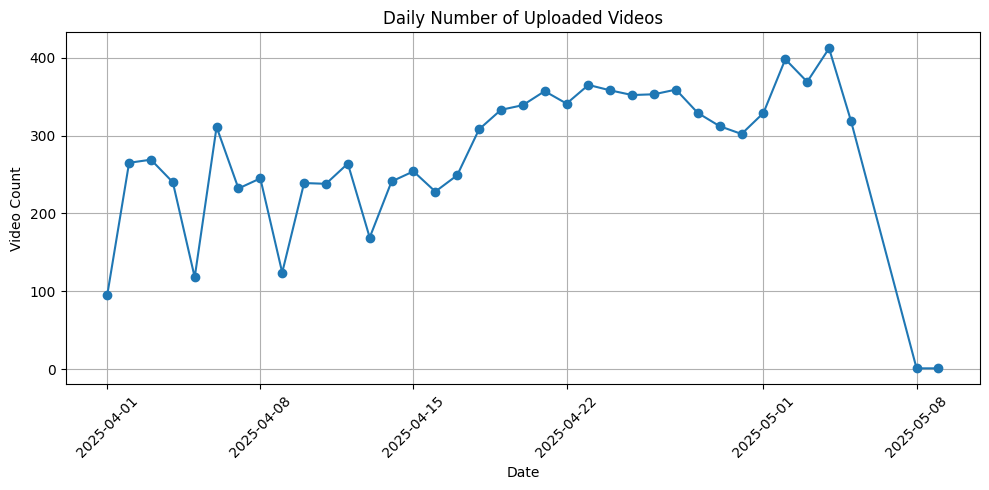

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [171]:
# Convert 'publishedAt' to datetime format
df['snippet.publishedAt'] = pd.to_datetime(df['snippet.publishedAt'])

# Extract date only for daily aggregation
df['published_date'] = df['snippet.publishedAt'].dt.date

# Count number of videos published per day
daily_counts = df.groupby('published_date').size()

# Plot daily upload count
plt.figure(figsize=(10, 5))
daily_counts.plot(kind='line', marker='o')
plt.title('Daily Number of Uploaded Videos')
plt.xlabel('Date')
plt.ylabel('Video Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Convert published_date to datetime and use it as index
df['published_date'] = pd.to_datetime(df['snippet.publishedAt']).dt.date
df['statistics.viewCount'] = df['statistics.viewCount'].astype(int)

# Resample daily total views
daily_views = df.set_index(pd.to_datetime(df['published_date'])).resample('D')['statistics.viewCount'].sum()

# Plot daily total view count
plt.figure(figsize=(10, 5))
daily_views.plot(kind='line', marker='o', color='orange')
plt.title('Daily Total View Count')
plt.xlabel('Date')
plt.ylabel('Total Views')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
widgets.IntSlider()

In [ ]:
# Convert 'publishedAt' to datetime and set as index
df['published_date'] = pd.to_datetime(df['snippet.publishedAt'])
df.set_index('published_date', inplace=True)

# Create date range for selection
date_range = df.index.sort_values()
start_date = widgets.SelectionSlider(
    options=date_range.strftime('%Y-%m-%d').tolist(),
    value=date_range.min().strftime('%Y-%m-%d'),
    description='Start:',
    layout={'width': '95%'}
)
end_date = widgets.SelectionSlider(
    options=date_range.strftime('%Y-%m-%d').tolist(),
    value=date_range.max().strftime('%Y-%m-%d'),
    description='End:',
    layout={'width': '95%'}
)

resolution = widgets.Dropdown(
    options=[('Hourly', 'H'),('Daily', 'D'), ('Weekly', 'W'), ('Monthly', 'M')],
    value='D',
    description='Resolution:'
)

# Function to plot total viewCount over time (daily resolution)
# Function to plot total viewCount over time with adjustable resolution
def plot_viewcount(start_str, end_str, freq):
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")
    df_filtered = df.loc[(df.index >= start) & (df.index <= end)]

    if df_filtered.empty:
        print("No data for selected range.")
        return

    # Resample viewCount according to selected frequency
    resampled = df_filtered['statistics.viewCount'].astype(int).resample(freq).sum()

    # Plotting
    plt.figure(figsize=(10, 5))
    resampled.plot(kind='line', marker='o', color='orange')
    plt.title(f'Total View Count ({freq} resolution)')
    plt.xlabel('Date')
    plt.ylabel('Total Views')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Display widgets and output
ui = widgets.VBox([start_date, end_date, resolution])
out = widgets.interactive_output(plot_viewcount, {
    'start_str': start_date,
    'end_str': end_date,
    'freq': resolution
})
display(ui, out)


In [ ]:
def plot_daily_video_count(series, freq):
    """
    Plot resampled series of video upload counts with time resolution.
    """
    plt.figure(figsize=(10, 5))
    series.plot(kind='line', marker='o')
    plt.title(f'Number of Uploaded Videos ({freq} resolution)')
    plt.xlabel('Date')
    plt.ylabel('Upload Count')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def update_plot(start_str, end_str, freq):
    start = pd.to_datetime(start_str).tz_localize("Australia/Melbourne")
    end = pd.to_datetime(end_str).tz_localize("Australia/Melbourne")
    df_filtered = df.loc[(df.index >= start) & (df.index <= end)]
    if df_filtered.empty:
        print("No data for selected range.")
        return
    resampled = df_filtered.resample(freq).size()
    plot_daily_video_count(resampled, freq)

ui = widgets.VBox([start_date, end_date, resolution])
out = widgets.interactive_output(update_plot, {
    'start_str': start_date,
    'end_str': end_date,
    'freq': resolution
})

display(ui, out)